In [ ]:

import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

from google.colab import drive
import os
import torch
import torch.nn as nn

from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import timm
from peft import LoraConfig, get_peft_model
import numpy as np
from sklearn.metrics import matthews_corrcoef, classification_report
import matplotlib.pyplot as plt
import json
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, classification_report

drive.mount('/content/drive')


os.makedirs('/content/drive/MyDrive/gastrovision_lora_checkpoints', exist_ok=True)
os.makedirs('/content/drive/MyDrive/medical_image_dataset', exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda


In [ ]:
dataseta = os.listdir('/content/drive/MyDrive/medical_image_dataset/Gastrovision/train')
(dataseta)

['Normal mucosa and vascular pattern in the large bowel',
 'Dyed-resection-margins',
 'Duodenal bulb',
 'Normal stomach',
 "Barrett's esophagus",
 'Small bowel_terminal ileum',
 'Normal esophagus',
 'Accessory tools',
 'Cecum',
 'Resected polyps',
 'Retroflex rectum',
 'Colorectal cancer',
 'Gastric polyps',
 'Colon polyps',
 'Pylorus',
 'Dyed-lifted-polyps',
 'Gastroesophageal_junction_normal z-line',
 'Blood in lumen',
 'Esophagitis',
 'Ileocecal valve']

In [ ]:
datasetb = os.listdir('/content/drive/MyDrive/medical_image_dataset/kvasir-capsule/train')
datasetb

['Erythema',
 'Ulcer',
 'Reduced mucosal view',
 'Pylorus',
 'Normal clean mucosa',
 'Lymphangiectasia',
 'Blood - fresh',
 'Ileocecal valve',
 'Erosion',
 'Foreign body',
 'Angiectasia']

In [ ]:

class GITransform:
    def __init__(self, is_training=True, img_size=224):
        self.is_training = is_training
        self.img_size = img_size


        self.train_transform = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.0),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2,
                                 saturation=0.2, hue=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])


        self.val_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])

    def __call__(self, img):
        if self.is_training:
            return self.train_transform(img)
        else:
            return self.val_transform(img)

def prepare_datasets(data_path):
    """
    Prepare training and validation datasets
    Assumes directory structure:
    data_path/
        train/
            class1/
            class2/
        val/
            class1/
            class2/
    """
    train_transform = GITransform(is_training=True)
    val_transform = GITransform(is_training=False)

    train_dataset = ImageFolder(
        root=os.path.join(data_path, 'train'),
        transform=train_transform
    )

    val_dataset = ImageFolder(
        root=os.path.join(data_path, 'val'),
        transform=val_transform
    )

    return train_dataset, val_dataset, train_dataset.classes

In [ ]:

def setup_model(num_classes, lora_r=16, lora_alpha=32, lora_dropout=0.1):
    """Setup ConvNeXt-V2 with LoRA"""

    model = timm.create_model('convnextv2_base',
                            pretrained=True,
                            num_classes=num_classes)

    lora_config = LoraConfig(
        r=lora_r,
        lora_alpha=lora_alpha,
        target_modules=["qkv", "fc1", "fc2"],
        lora_dropout=lora_dropout,
        bias="none",
    )


    model = get_peft_model(model, lora_config)

    model.print_trainable_parameters()

    return model

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

count_parameters(setup_model(num_classes=20))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


trainable params: 2,887,680 || all params: 90,600,980 || trainable%: 3.1873


2887680

In [ ]:
class GITrainer:
    def __init__(self, model, train_loader, val_loader, test_loader, optimizer, scheduler,
                 device, checkpoint_dir, class_names):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device = device
        self.checkpoint_dir = checkpoint_dir
        self.class_names = class_names

        self.criterion = nn.CrossEntropyLoss()

        self.epoch = 0
        self.global_step = 0
        self.best_accuracy = 0.0
        self.best_mcc = 0.0
        self.train_losses = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []

    def calculate_accuracy(self, loader, is_training=True):
        """Calculate accuracy and loss for train or validation"""
        if is_training:
            self.model.train()
        else:
            self.model.eval()

        running_loss = 0.0
        correct = 0
        total = 0

        with torch.set_grad_enabled(is_training):
            for images, targets in loader:
                images, targets = images.to(self.device), targets.to(self.device)
                outputs = self.model(images)
                loss = self.criterion(outputs, targets)
                running_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total += targets.size(0)
                correct += (predicted == targets).sum().item()

        accuracy = 100 * correct / total
        avg_loss = running_loss / len(loader)

        return avg_loss, accuracy

    def train_epoch(self):
        """Train one epoch with checkpoint every 25 batches"""
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        progress_bar = tqdm(self.train_loader, desc=f'Epoch {self.epoch+1}')

        for batch_idx, (images, targets) in enumerate(progress_bar):
            images, targets = images.to(self.device), targets.to(self.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.criterion(outputs, targets)
            loss.backward()
            self.optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

            self.global_step += 1


            batch_accuracy = 100 * (predicted == targets).sum().item() / targets.size(0)
            progress_bar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{batch_accuracy:.2f}%'
            })

            if (batch_idx + 1) % 25 == 0:
                self.save_checkpoint()

        epoch_loss = running_loss / len(self.train_loader)
        epoch_accuracy = 100 * correct / total

        return epoch_loss, epoch_accuracy

    def save_checkpoint(self, is_best=False):
        """Save checkpoint that can resume training exactly"""
        checkpoint = {
            'epoch': self.epoch,
            'global_step': self.global_step,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'scheduler_state_dict': self.scheduler.state_dict() if self.scheduler else None,
            'best_accuracy': self.best_accuracy,
            'best_mcc': self.best_mcc,
            'train_losses': self.train_losses,
            'val_losses': self.val_losses,
            'train_accuracies': self.train_accuracies,
            'val_accuracies': self.val_accuracies,
            'class_names': self.class_names
        }

        latest_path = os.path.join(self.checkpoint_dir, 'latest_checkpoint.pth')
        torch.save(checkpoint, latest_path)

        if is_best:
            best_path = os.path.join(self.checkpoint_dir, 'best_checkpoint.pth')
            torch.save(checkpoint, best_path)

        print(f"💾 Checkpoint saved - Epoch {self.epoch}, Global Step {self.global_step}")

    def load_checkpoint(self):
        """Load checkpoint to resume training"""
        checkpoint_path = os.path.join(self.checkpoint_dir, 'latest_checkpoint.pth')
        if os.path.exists(checkpoint_path):
            try:
                print("🔄 Loading checkpoint...")
                checkpoint = torch.load(checkpoint_path, map_location=self.device)


                self.model.load_state_dict(checkpoint['model_state_dict'])

                self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

                if self.scheduler and checkpoint['scheduler_state_dict']:
                    self.scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

                self.epoch = checkpoint['epoch']
                self.global_step = checkpoint['global_step']
                self.best_accuracy = checkpoint['best_accuracy']
                self.best_mcc = checkpoint['best_mcc']
                self.train_losses = checkpoint['train_losses']
                self.val_losses = checkpoint['val_losses']
                self.train_accuracies = checkpoint['train_accuracies']
                self.val_accuracies = checkpoint['val_accuracies']

                print(f"Successfully loaded checkpoint:")
                print(f"Epoch: {self.epoch}")
                print(f"Global Step: {self.global_step}")
                print(f"Best Val Accuracy: {self.best_accuracy/100:.4f}")
                return True

            except Exception as e:
                print(f"Error loading checkpoint: {e}")
                return False
        else:
            print("No checkpoint found - starting from scratch")
            return False

    def train(self, num_epochs, resume=True):
        """Main training loop - FIXED SCHEDULER"""
        start_epoch = 0

        if resume:
            if self.load_checkpoint():
                start_epoch = self.epoch + 1
                print(f"Resuming from epoch {start_epoch}")
            else:
                print("Starting training from scratch")
                start_epoch = 0

        for epoch in range(start_epoch, num_epochs):
            self.epoch = epoch
            print(f"\nEpoch {epoch+1}/{num_epochs}")


            train_loss, train_accuracy = self.train_epoch()
            self.train_losses.append(train_loss)
            self.train_accuracies.append(train_accuracy)


            val_loss, val_accuracy = self.calculate_accuracy(self.val_loader, is_training=False)
            self.val_losses.append(val_loss)
            self.val_accuracies.append(val_accuracy)

            print(f"Epoch Summary - Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy/100:.4f}")
            print(f"Epoch Summary - Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy/100:.4f}")


            is_best = val_accuracy > self.best_accuracy
            if is_best:
                self.best_accuracy = val_accuracy
                print(f"🏆 Best Validation Accuracy: {self.best_accuracy/100:.4f}")
            else:
                print(f"Best Validation Accuracy: {self.best_accuracy/100:.4f}")


            if self.scheduler:
                self.scheduler.step(val_accuracy)
                current_lr = self.optimizer.param_groups[0]['lr']


                if not hasattr(self, 'previous_lr'):
                    self.previous_lr = current_lr

                if current_lr != self.previous_lr:
                    print(f"LR CHANGED: {self.previous_lr} → {current_lr}")
                    self.previous_lr = current_lr


            self.save_checkpoint(is_best=is_best)

After the 9th epoch there was slight change in the optimizer by adding a wt decay of ***0.01***

In [ ]:
def main_training_script():

    config = {
        'data_path': '/content/drive/MyDrive/medical_image_dataset/Gastrovision',
        'batch_size': 32,
        'num_epochs': 15,
        'learning_rate': 1e-4,
        'lora_r': 16,
        'lora_alpha': 32,
        'img_size': 224,
        'checkpoint_dir': '/content/drive/MyDrive/gastrovision_lora_checkpoints'
    }

    global device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    if device.type == 'cuda':
        print(f"GPU: {torch.cuda.get_device_name(0)}")


    checkpoint_path = os.path.join(config['checkpoint_dir'], 'latest_checkpoint.pth')
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=device)
        print("CHECKPOINT FOUND - WILL RESUME TRAINING")
        print(f"Previous training: Epoch {checkpoint['epoch'] + 1}, Best Acc: {checkpoint['best_accuracy']/100:.4f}")
    else:
        print("NO CHECKPOINT - STARTING FRESH TRAINING")


    train_dataset, val_dataset, class_names = prepare_datasets(config['data_path'])


    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'],
                             shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=config['batch_size'],
                           shuffle=False, num_workers=2)
    test_loader = val_loader

    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    print(f"Number of Classes: {len(class_names)}")


    model = setup_model(num_classes=len(class_names),
                       lora_r=config['lora_r'],
                       lora_alpha=config['lora_alpha'])
    model = model.to(device)


    optimizer = torch.optim.AdamW(model.parameters(), lr=config['learning_rate'], weight_decay=0.0)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        patience=5,
        factor=0.5,
        min_lr=1e-6,
    )


    trainer = GITrainer(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        checkpoint_dir=config['checkpoint_dir'],
        class_names=class_names
    )


    trainer.train(num_epochs=config['num_epochs'], resume=True)

    return trainer

print("STARTING TRAINING WITH PAPER METHODOLOGY...")
trainer = main_training_script()

🚀 STARTING TRAINING WITH PAPER METHODOLOGY...
Using device: cuda
GPU: Tesla T4
✅ CHECKPOINT FOUND - WILL RESUME TRAINING
   Previous training: Epoch 25, Best Acc: 0.8669
📊 Training samples: 6298
📊 Validation samples: 789
🎯 Number of Classes: 20
trainable params: 2,887,680 || all params: 90,600,980 || trainable%: 3.1873
🔄 Loading checkpoint...
✅ Successfully loaded checkpoint:
   📅 Epoch: 24
   🔢 Global Step: 4903
   🏆 Best Val Accuracy: 0.8669
🔄 Resuming from epoch 25


THIS IS THE EVLAUTION PHASE


In [ ]:
!pip install grad-cam captum opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 65.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 61.9 MB/s eta 0:00:00
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=04be59920e63586828e208568fb9abead127b4521ad72f8cfb8590f0de24bea2
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
  Attempting uninstall: numpy
  

In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import timm
from peft import LoraConfig, get_peft_model
import numpy as np
from sklearn.metrics import matthews_corrcoef, classification_report
import matplotlib.pyplot as plt
import json
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, classification_report


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import torch
import timm
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
from torchvision import transforms
from peft import LoraConfig, get_peft_model
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [ ]:
BEST_CKPT_PATH = "/content/drive/MyDrive/gastrovision_lora_checkpoints/best_checkpoint.pth"

if not os.path.exists(BEST_CKPT_PATH):
    raise FileNotFoundError(f"Not found: {BEST_CKPT_PATH}")

ckpt = torch.load(BEST_CKPT_PATH, map_location=device)

state_dict  = ckpt["model_state_dict"]
class_names = ckpt["class_names"]
num_classes = len(class_names)

print("Loaded trained checkpoint")
print("Num classes:", num_classes)

✅ Loaded trained checkpoint
✅ Num classes: 20


In [ ]:
base_model = timm.create_model("convnextv2_base", pretrained=False, num_classes=num_classes)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["qkv", "fc1", "fc2"],
    lora_dropout=0.1,
    bias="none",
)

model = get_peft_model(base_model, lora_config).to(device)

missing, unexpected = model.load_state_dict(state_dict, strict=False)
model.eval()

print("Loaded your weights into the model")
print("Missing keys:", len(missing), "| Unexpected keys:", len(unexpected))
if len(unexpected) > 0:
    print("Sample unexpected:", unexpected[:10])


✅ Loaded your weights into the model
Missing keys: 0 | Unexpected keys: 0


In [ ]:
import torch
import os

BEST_CKPT_PATH = "/content/drive/MyDrive/gastrovision_lora_checkpoints/best_checkpoint.pth"

if 'device' not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if os.path.exists(BEST_CKPT_PATH):
    print(f"Loading checkpoint from: {BEST_CKPT_PATH}")
    checkpoint = torch.load(BEST_CKPT_PATH, map_location=device)

    print("\nKeys found in the checkpoint file:")
    for key in checkpoint.keys():
        if key == 'model_state_dict':
            print(f"- {key} (contains model's weights)")
        elif key == 'optimizer_state_dict':
            print(f"- {key} (contains optimizer's state)")
        elif key == 'scheduler_state_dict':
            print(f"- {key} (contains scheduler's state)")
        elif key == 'class_names':
            print(f"length of classes: {len(checkpoint[key])}")
            print(f"- {key}: {checkpoint[key]}")
        else:
            print(f"- {key}: {checkpoint[key]}")
else:
    print(f"Checkpoint file not found at: {BEST_CKPT_PATH}")

Loading checkpoint from: /content/drive/MyDrive/Qlora_checkpoint(20 classes)/best_checkpoint.pth

Keys found in the checkpoint file:
- epoch: 8
- global_step: 1773
- model_state_dict (contains model's weights)
- optimizer_state_dict (contains optimizer's state)
- scheduler_state_dict (contains scheduler's state)
- best_accuracy: 86.69201520912547
- best_mcc: 0.0
- train_losses: [1.6837337670592487, 0.7852449575959123, 0.5951155814422568, 0.4922422232664176, 0.4319995342928746, 0.3763491347205215, 0.3316392945834828, 0.3036175784347626, 0.27444945688023786]
- val_losses: [0.936676652431488, 0.640965343862772, 0.5614132362604142, 0.4777653528749943, 0.46853917330503464, 0.47409238904714585, 0.43641615778207776, 0.42854683272540567, 0.4442456515133381]
- train_accuracies: [53.20736741822801, 76.67513496348047, 81.67672276913306, 84.58240711336933, 86.09082248332804, 87.8215306446491, 89.34582407113369, 90.20323912353128, 91.15592251508416]
- val_accuracies: [71.73637515842839, 80.73510773

In [ ]:
from google.colab import files
import os
import glob

print("Please select the images for inference:")
uploaded = files.upload()

extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.PNG']
img_paths = []
for ext in extensions:
    img_paths.extend(glob.glob(os.path.join('/content', ext)))

img_paths = sorted(list(set(img_paths)))

print(f"\n Found {len(img_paths)} images in /content ready for processing.")

Please select the images for inference:


Saving normal_stomach.jpg to normal_stomach.jpg
Saving colon_polybs.jpg to colon_polybs.jpg
Saving 81cd157d-1f8b-4a15-a3d8-fb6493579b95.jpg to 81cd157d-1f8b-4a15-a3d8-fb6493579b95.jpg
Saving 9aca37dc-fe5e-47ae-8fd6-083ce4e61ba1.jpg to 9aca37dc-fe5e-47ae-8fd6-083ce4e61ba1.jpg
Saving 6e94d6c3-6c26-497d-965a-edf351d76910.jpg to 6e94d6c3-6c26-497d-965a-edf351d76910.jpg
Saving 0bebf85c-07c5-47f3-a0eb-8aebfca6a874.jpg to 0bebf85c-07c5-47f3-a0eb-8aebfca6a874.jpg

✅ Found 6 images in /content ready for processing.


Processing images in this order: ['81cd157d-1f8b-4a15-a3d8-fb6493579b95.jpg', '9aca37dc-fe5e-47ae-8fd6-083ce4e61ba1.jpg', '0bebf85c-07c5-47f3-a0eb-8aebfca6a874.jpg', 'colon_polybs.jpg', 'normal_stomach.jpg', '6e94d6c3-6c26-497d-965a-edf351d76910.jpg']


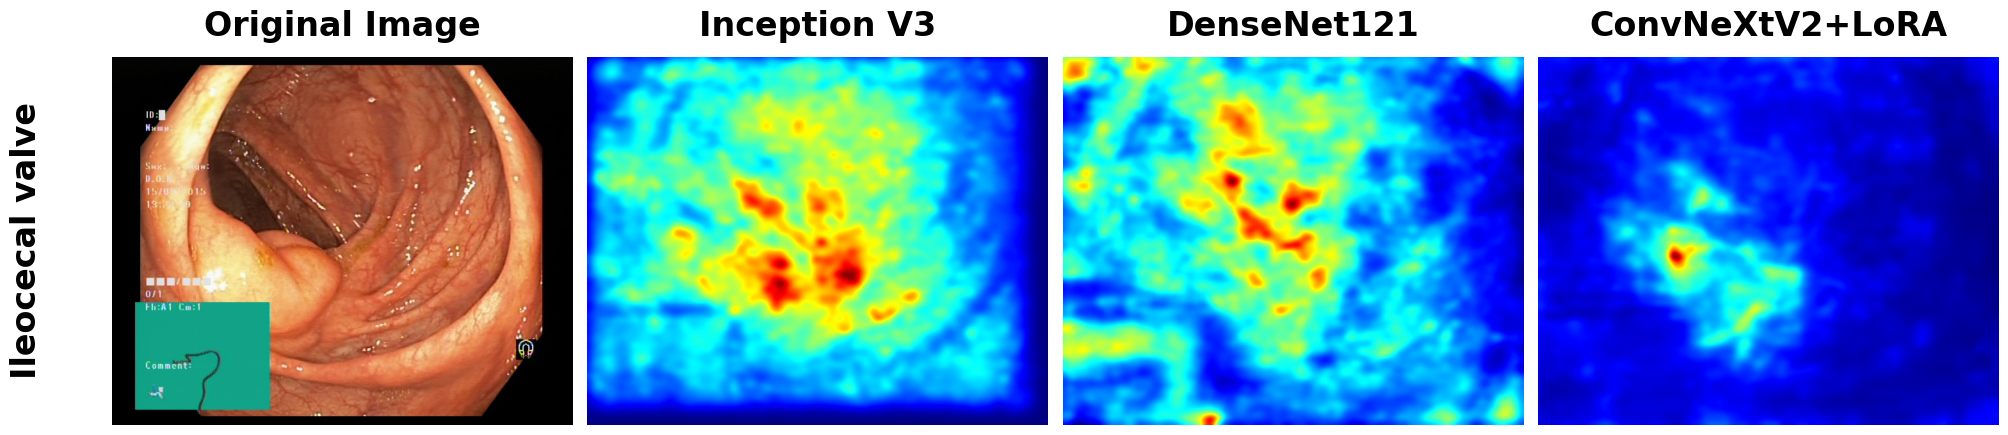

Results for 81cd157d-1f8b-4a15-a3d8-fb6493579b95.jpg: ['Inception V3: Dyed-resection-margins (12.8%)', 'DenseNet121: Blood in lumen (13.6%)', 'ConvNeXtV2+LoRA: Ileocecal valve (66.5%)']


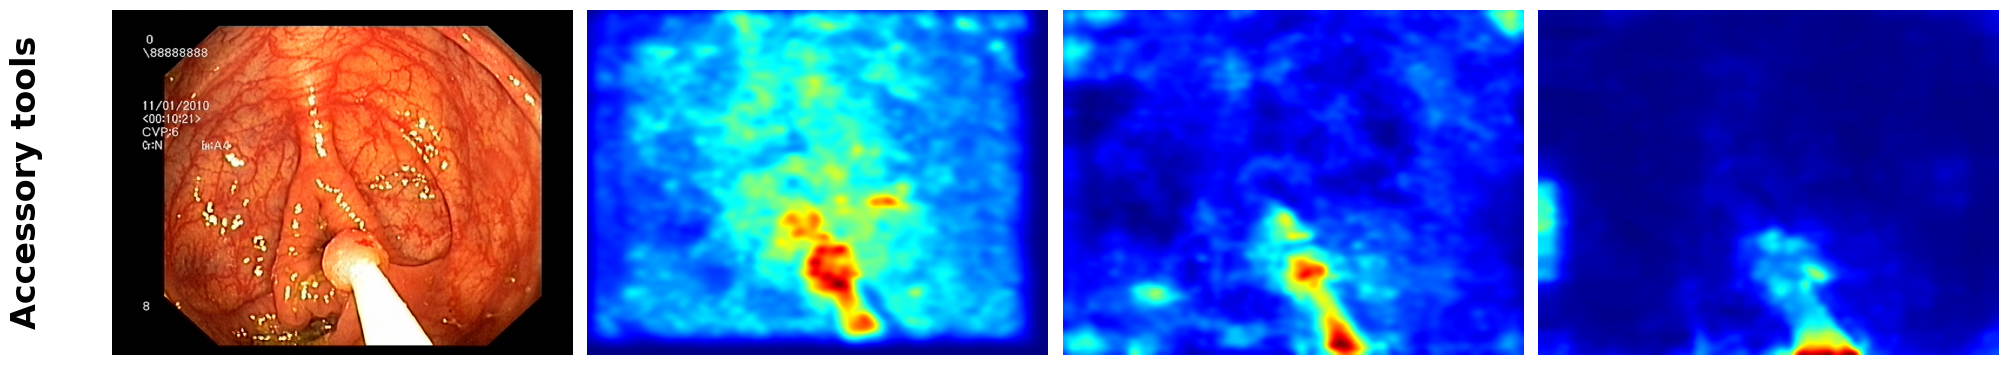

Results for 9aca37dc-fe5e-47ae-8fd6-083ce4e61ba1.jpg: ['Inception V3: Gastroesophageal_junction_normal z-line (8.6%)', 'DenseNet121: Gastroesophageal_junction_normal z-line (12.2%)', 'ConvNeXtV2+LoRA: Accessory tools (98.4%)']


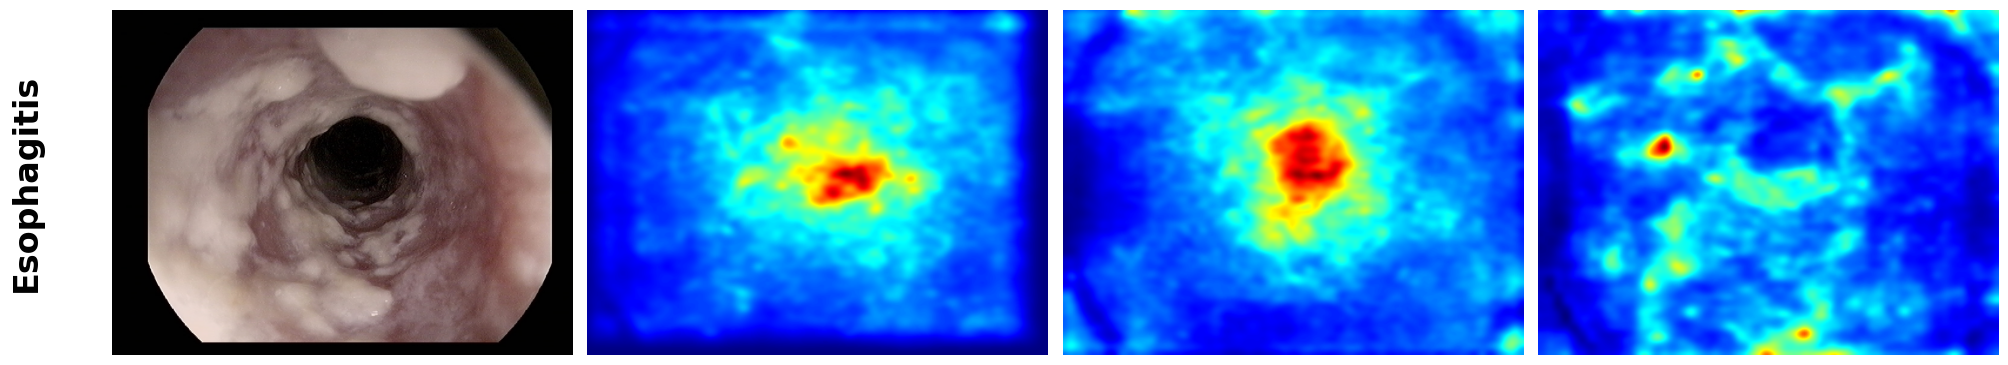

Results for 0bebf85c-07c5-47f3-a0eb-8aebfca6a874.jpg: ['Inception V3: Accessory tools (9.9%)', 'DenseNet121: Normal esophagus (14.2%)', 'ConvNeXtV2+LoRA: Esophagitis (54.4%)']


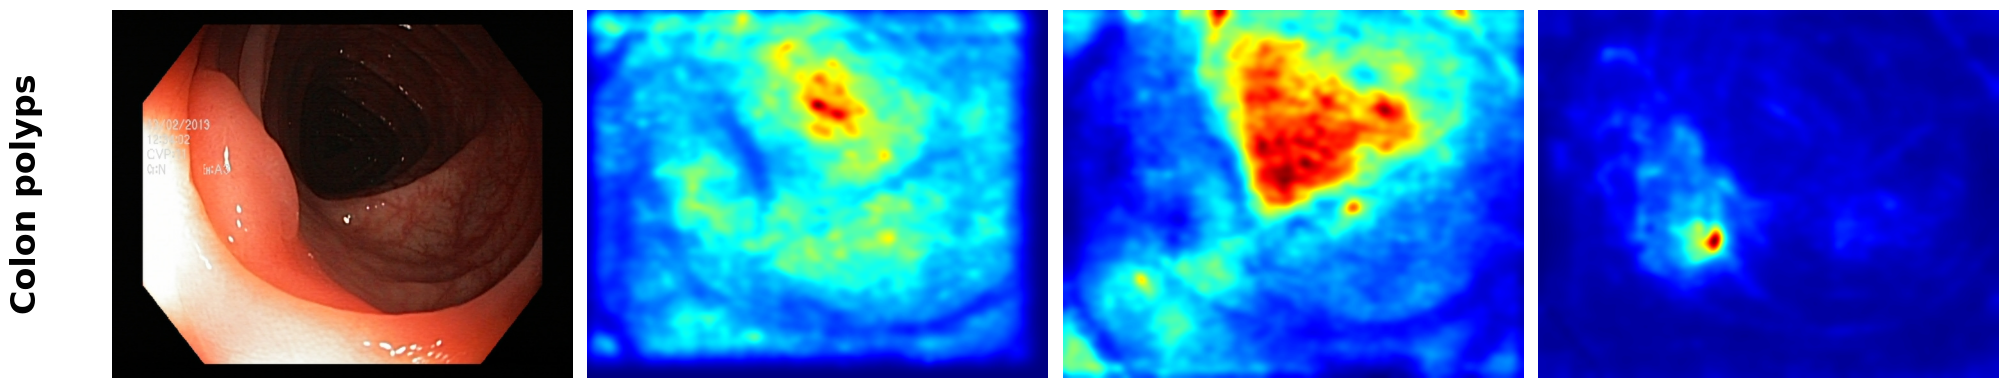

Results for colon_polybs.jpg: ['Inception V3: Dyed-resection-margins (9.4%)', 'DenseNet121: Normal esophagus (8.3%)', 'ConvNeXtV2+LoRA: Colon polyps (97.2%)']


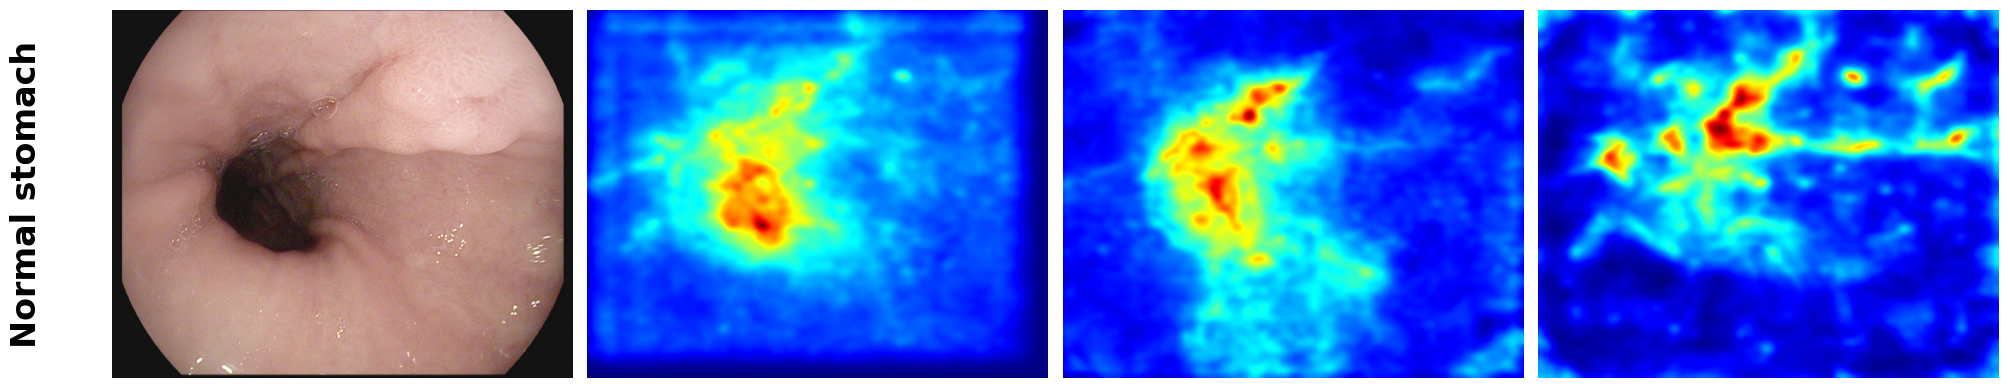

Results for normal_stomach.jpg: ['Inception V3: Accessory tools (9.2%)', 'DenseNet121: Gastroesophageal_junction_normal z-line (11.4%)', 'ConvNeXtV2+LoRA: Normal stomach (54.4%)']


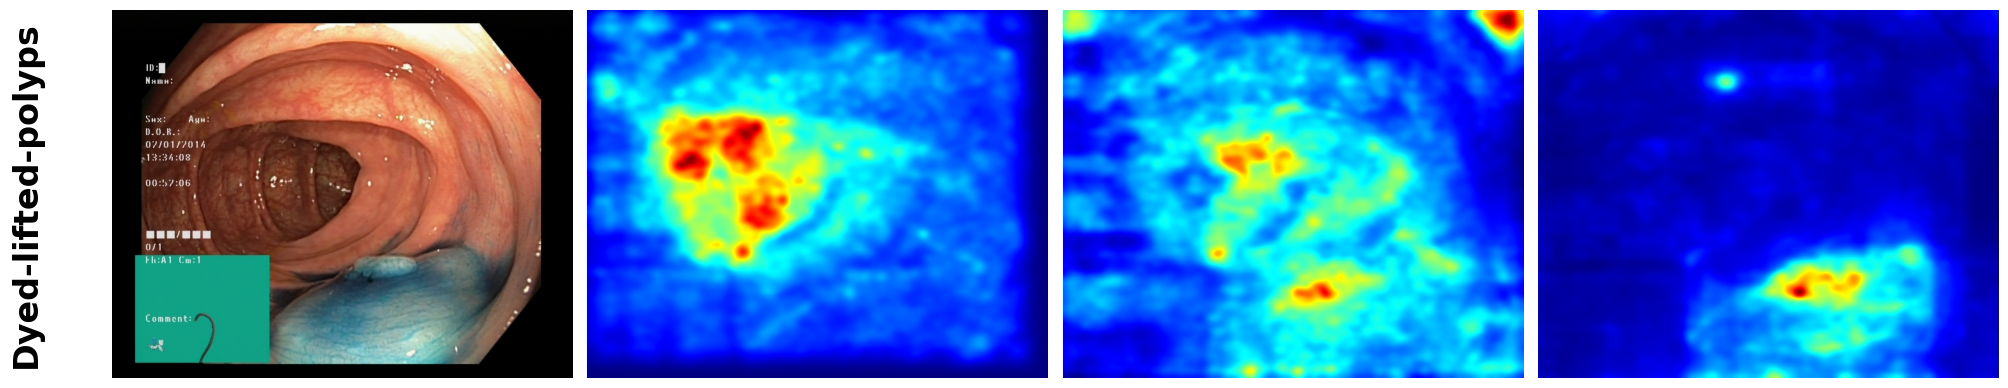

Results for 6e94d6c3-6c26-497d-965a-edf351d76910.jpg: ['Inception V3: Duodenal bulb (12.5%)', 'DenseNet121: Gastroesophageal_junction_normal z-line (13.7%)', 'ConvNeXtV2+LoRA: Dyed-lifted-polyps (98.8%)']


In [ ]:
import numpy as np
import cv2

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
from scipy.ndimage import gaussian_filter
from captum.attr import Saliency, NoiseTunnel

def process_saliency_to_heatmap(sg_tensor, orig_h, orig_w, blur_sigma=2.0):
    sg_np = sg_tensor.detach().cpu().numpy()
    sg_map = np.abs(sg_np[0]).sum(axis=0)
    sg01 = sg_map.astype(np.float32)
    sg01 -= sg01.min()
    sg01 /= (sg01.max() + 1e-8)
    sg01_blurred = gaussian_filter(sg01, sigma=blur_sigma)
    sg01_blurred -= sg01_blurred.min()
    sg01_blurred /= (sg01_blurred.max() + 1e-8)
    sg01_resized = cv2.resize(sg01_blurred, (orig_w, orig_h))
    u8 = (np.clip(sg01_resized, 0, 1) * 255).astype(np.uint8)
    heat = cv2.applyColorMap(u8, cv2.COLORMAP_JET)
    return cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)

def logits_only(m, x):
    out = m(x)
    return out if isinstance(out, torch.Tensor) else out[0]

IMG_SIZE = 224
BLUR_SIGMA = 2.0
NT_SAMPLES = 25
STDEV = 0.15
FONT_SIZE = 24

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

if 'img_paths' in locals() and len(img_paths) >= 4:

    p = img_paths
    reordered_paths = [p[2], p[3], p[0]] + p[4:] + [p[1]]

    print(f"Processing images in this order: {[os.path.basename(f) for f in reordered_paths]}")

    COL_TITLES = ["Original Image", "Inception V3", "DenseNet121", "ConvNeXtV2+LoRA"]
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    from torchvision import models
    m1 = models.inception_v3(weights='DEFAULT', aux_logits=True).to(device)
    m1.fc = nn.Linear(m1.fc.in_features, num_classes).to(device)
    m2 = models.densenet121(weights='DEFAULT').to(device)
    m2.classifier = nn.Linear(m2.classifier.in_features, num_classes).to(device)

    model.to(device)
    models_dict = {"Inception V3": m1, "DenseNet121": m2, "ConvNeXtV2+LoRA": model}

    for idx, img_path in enumerate(reordered_paths):
        try:
            pil_orig = Image.open(img_path).convert("RGB")
            orig = np.array(pil_orig)
            H0, W0 = orig.shape[:2]
            x = transform(pil_orig).unsqueeze(0).to(device)

            heatmaps = [orig]
            predictions = []

            for name, m in models_dict.items():
                m.eval()
                with torch.no_grad():
                    logits = logits_only(m, x)
                    probs = torch.softmax(logits, dim=1)
                    pred_idx = torch.argmax(probs, dim=1).item()

                pred_name = class_names[pred_idx]
                predictions.append(f"{name}: {pred_name} ({probs[0, pred_idx]:.1%})")

                st = Saliency(m)
                nt = NoiseTunnel(st)
                x_attr = x.clone().detach().requires_grad_(True).to(device)
                sg = nt.attribute(x_attr, target=pred_idx, nt_type='smoothgrad', nt_samples=NT_SAMPLES, stdevs=STDEV)
                heatmaps.append(process_saliency_to_heatmap(sg, H0, W0))

            fig, axs = plt.subplots(1, 4, figsize=(20, 6), dpi=100)
            for i, ax in enumerate(axs):
                ax.imshow(heatmaps[i])
                ax.axis("off")

                \
                if idx == 0:
                    ax.set_title(COL_TITLES[i], fontsize=FONT_SIZE, fontweight='bold', pad=15)

                if i == 0:
                    with torch.no_grad():
                        main_logits = logits_only(model, x)
                        main_label = class_names[torch.argmax(main_logits, dim=1).item()]
                    ax.text(-0.15, 0.5, main_label, transform=ax.transAxes, rotation='vertical',
                            va='center', ha='right', fontsize=FONT_SIZE, fontweight='bold')

            plt.tight_layout()
            plt.show()
            print(f"Results for {os.path.basename(img_path)}: {predictions}")
        except Exception as e:
            print(f"Error on {img_path}: {e}")
else:
    print("Please upload at least 4 images to perform this specific reordering.")